In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
dataset=pd.read_csv('Startups.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [17]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [18]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,74713.570790,122491.41804,197658.823100,112969.840760
std,43829.760036,27533.95280,123515.190178,36911.404076
min,0.000000,25060.33000,0.000000,14681.400000
25%,42516.265000,103382.94500,107048.970000,86110.120000
50%,72652.560000,122535.14500,198950.300000,111591.590000
75%,102808.087500,142164.29250,278839.760000,137646.112500
max,221090.730000,198895.99000,619279.430000,229359.120000


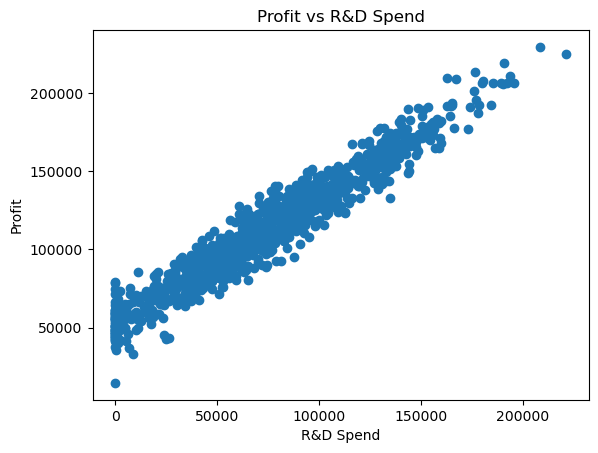

In [19]:
plt.scatter(X[:,0],y)
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('Profit vs R&D Spend')
plt.show()

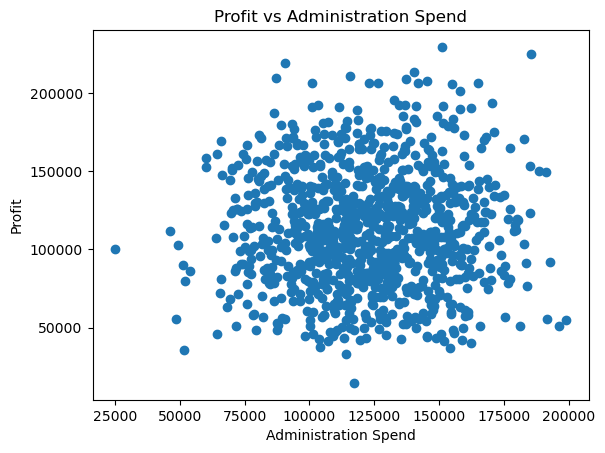

In [20]:
plt.scatter(X[:,1],y)
plt.xlabel('Administration Spend')
plt.ylabel('Profit')
plt.title('Profit vs Administration Spend')
plt.show()

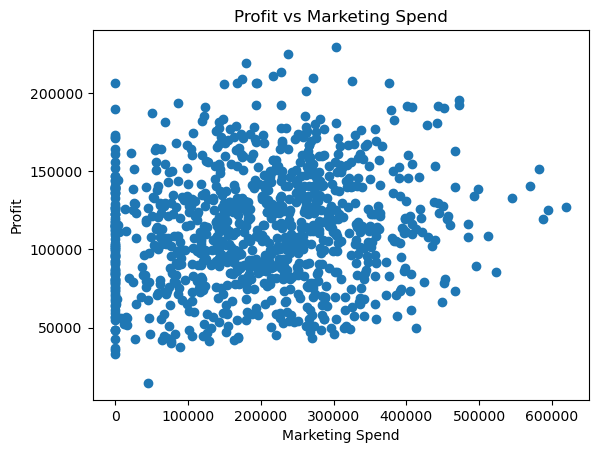

In [21]:
plt.scatter(X[:,2],y)
plt.xlabel('Marketing Spend')
plt.ylabel('Profit')
plt.title('Profit vs Marketing Spend')
plt.show()

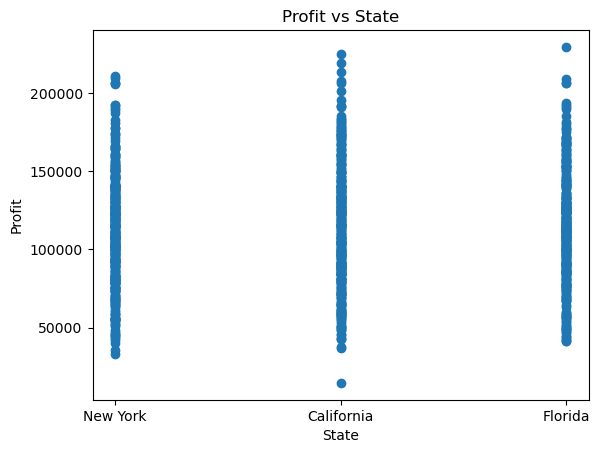

In [22]:
plt.scatter(X[:,3],y)
plt.xlabel('State')
plt.ylabel('Profit')
plt.title('Profit vs State')
plt.show()

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [24]:
print(X)

[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 ...
 [0.0 1.0 0.0 128220.58 86422.93 306302.29]
 [0.0 0.0 1.0 127216.32 122488.4 381749.58]
 [0.0 0.0 1.0 65831.75 123685.25 96519.01]]


In [25]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [26]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

--- Model Evaluation Metrics ---
R-Squared Score: 0.9376
Mean Squared Error (MSE): 83007890.00


In [28]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)    
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[128019.01 135878.13]
 [ 60919.53  71629.19]
 [121804.03 103529.53]
 [ 82402.01  90189.93]
 [105575.1  102729.44]
 [117384.55 119331.87]
 [115235.64 105008.31]
 [125826.56 123701.93]
 [107522.04 103551.45]
 [ 98708.94 102243.29]
 [160970.03 166991.85]
 [119250.84 118469.09]
 [ 66428.7   73938.96]
 [ 69230.68  67487.74]
 [133292.6  143996.83]
 [ 68423.72  76003.85]
 [ 76712.14  74386.94]
 [147128.47 161131.35]
 [151214.79 132602.65]
 [ 70202.04  76878.56]
 [ 99065.73  97483.56]
 [ 54805.66  47042.83]
 [ 75290.75  75395.05]
 [133609.84 146735.61]
 [ 81681.81  96125.25]
 [ 99256.94 101865.72]
 [ 48220.22  64926.08]
 [163478.38 190000.36]
 [101750.85  97445.78]
 [190227.49 191792.06]
 [145094.28 155843.98]
 [ 47538.06  48450.05]
 [140229.44 150924.48]
 [120195.19 117714.45]
 [ 83019.86  67757.94]
 [151894.38 143710.12]
 [134472.57 141223.48]
 [145931.08 151862.53]
 [ 77161.63  70876.99]
 [129177.5  146357.64]
 [118836.33 118851.82]
 [103572.73 122351.51]
 [ 53794.69  71342.23]
 [ 83864.56